In [ ]:
import numpy as np
import pandas as pd

import simulator
import generator
import eval

import matplotlib.pyplot as plt

import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance,chi2,skew, kurtosis,energy_distance
from scipy.spatial.distance import cdist, pdist

In [24]:
import warnings
warnings.simplefilter("ignore", category=FutureWarning)

## Ground Truth Series

In [2]:
NSIM = 100
LEN_HIST = 252
LEN_SEED = 25
LOOKBACK = 20
LEN_FUTURE = 60

In [3]:
"""GBM"""
sim_args = {
    'mu': 0.10,
    'sigma': 0.30,
    'dt' : 1/252,
    'seed': 42
}
# generate an observable path
hist_price = simulator.gbm(N=1, T=LEN_HIST, S0=100, **sim_args)[0]
hist_logret = simulator.prices_to_logreturns(hist_price, axis=-1)

# simulate future paths from ground thruth
fut_prices = simulator.gbm(N=NSIM, T=LEN_FUTURE, S0=hist_price[-1], **sim_args)
fut_logrets = simulator.prices_to_logreturns(fut_prices, axis=-1)

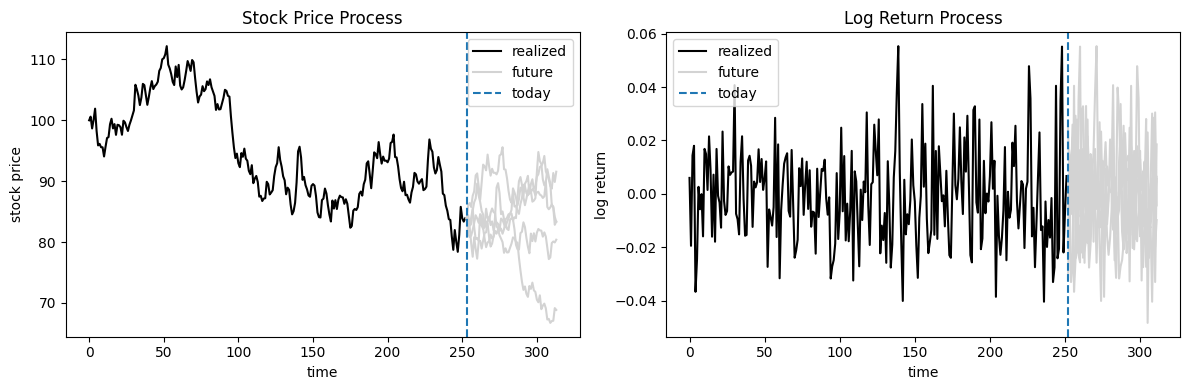

In [4]:
eval.plot_true_series(hist_price, hist_logret, fut_prices[:10], fut_logrets[:10])

## Generate Series with Different Generators

In [5]:
gen_logret = dict()
gen_price = dict()

In [6]:
# Pathwise Bootstrap
gen_bs = generator.BootstrapPathwise(
    lookback=LOOKBACK, sig_level=2, forward=5, dt=1, k=10,
    neighbor_weighting="softmax", random_state=42
).fit_logrets([hist_logret])

gen_logret['bootstrap'] = np.array([
    gen_bs.generate_logrets(
        seed_path=hist_logret[-LEN_SEED:], n_total_steps=LEN_SEED+LEN_FUTURE, return_full_path=False
    ) for _ in range(NSIM)])
gen_price['bootstrap'] = generator.logrets_to_prices(gen_logret['bootstrap'], hist_price[-1])[:,1:]

100%|█████████████████████████████████████████████████████████████████████████████| 227/227 [00:00<00:00, 37864.67it/s]


In [7]:
# Hybrid KRR and Bootstrap
gen_hb = generator.HybridKRRBootstrap(
    lookback=LOOKBACK, sig_level=2, dt=1, k=10, lam = 1,
    neighbor_weighting="softmax", random_state=42
).fit_logrets([hist_logret])

gen_logret['hybrid'] = np.array([
    gen_hb.generate_logrets(
        seed_path=hist_logret[-LEN_SEED:], n_total_steps=LEN_SEED+LEN_FUTURE, return_full_path=False
    ) for _ in range(NSIM)])
gen_price['hybrid'] = generator.logrets_to_prices(gen_logret['hybrid'], hist_price[-1])[:,1:]

100%|█████████████████████████████████████████████████████████████████████████████| 232/232 [00:00<00:00, 29019.40it/s]


In [8]:
# KRR
gen_krr = generator.KRRSignature(
    lookback=LOOKBACK, sig_level=2, dt=1, lam_mu = 1, lam_sig = 1, random_state=42
).fit_logrets([hist_logret])

gen_logret['krr'] = np.array([
    gen_krr.generate_logrets(
        seed_path=hist_logret[-LEN_SEED:], n_total_steps=LEN_SEED+LEN_FUTURE, return_full_path=False
    ) for _ in range(NSIM)])
gen_price['krr'] = generator.logrets_to_prices(gen_logret['krr'], hist_price[-1])[:,1:]

In [9]:
# ARIMA
gen_arima = generator.ARIMAGen(order=(1,0,1), trend='c', random_state=42).fit_logrets(hist_logret)

gen_logret['arima'] = np.array([gen_arima.generate_logrets(n_steps=LEN_FUTURE) for _ in range(NSIM)])
gen_price['arima'] = generator.logrets_to_prices(gen_logret['arima'], hist_price[-1])[:,1:]

In [10]:
# GARCH
gen_garch = generator.GARCHGen(p=1,q=1,dist='t',random_state=42,scale='auto').fit_logrets(hist_logret)

gen_logret['garch'] = np.array(
    [gen_garch.generate_logrets(n_steps=LEN_FUTURE, seed_returns=hist_logret[-LEN_SEED:]) for _ in range(NSIM)])
gen_price['garch'] = generator.logrets_to_prices(gen_logret['garch'], hist_price[-1])[:,1:]

## Distribution Comparison

Generating method: bootstrap


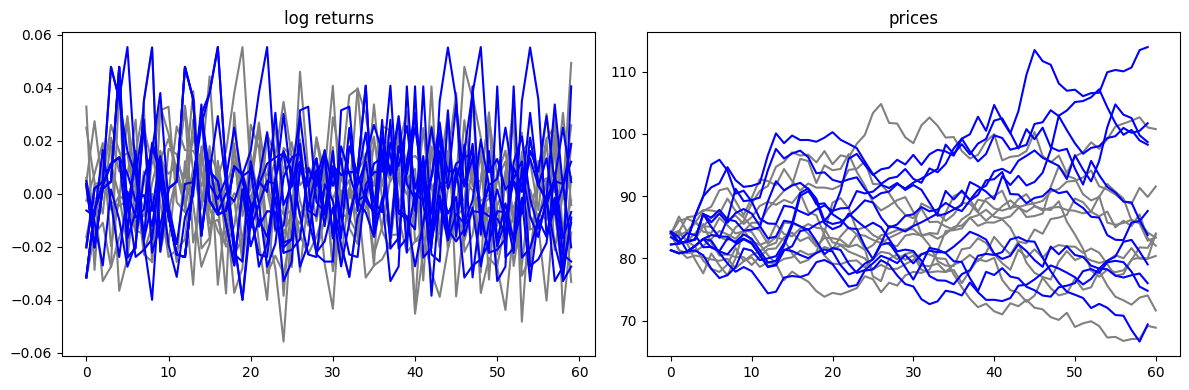

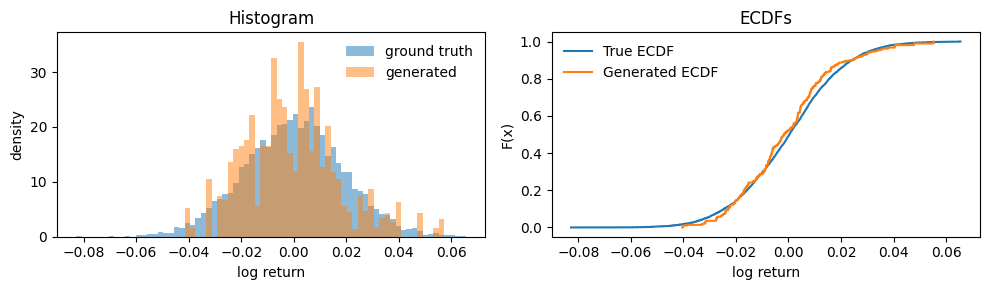

In [11]:
NSHOW = 10
METHOD = 'bootstrap'

print("Generating method:", METHOD)
eval.plot_series_compare(fut_logrets[:NSHOW], fut_prices[:NSHOW], gen_logret[METHOD][:NSHOW], gen_price[METHOD][:NSHOW])
eval.plot_dist_compare(fut_logrets, gen_logret[METHOD])

## Signature MMD

In [12]:
mmd = dict()
for method in gen_price.keys():
    mmd[method] = eval.mmd_signature_linear(
        np.arange(LEN_FUTURE), gen_price[method], fut_prices[:,1:], window_size=5, sig_level=2)

In [13]:
pd.DataFrame(pd.Series(mmd))

,0
bootstrap,0.139669
hybrid,0.035445
krr,1.219328
arima,0.180320
garch,0.711483


In [15]:
def evaluate_models(fut_prices, fut_logrets, gen_price, gen_logret, use="logret"):
    """
    Compare generated paths to GBM ground truth using your moment_check().

    Parameters
    ----------
    fut_prices   : (NSIM, LEN_FUTURE+1) GBM price paths
    fut_logrets  : (NSIM, LEN_FUTURE)   GBM log-returns
    gen_price    : dict[name -> (NSIM, LEN_FUTURE)]   generated prices
    gen_logret   : dict[name -> (NSIM, LEN_FUTURE)]   generated log-returns
    use          : "logret" or "price"  (which domain to evaluate in)

    Returns
    -------
    results : dict[name -> dict with metrics]
    """
    results = {}

    if use == "logret":
        gt = fut_logrets                           # (NSIM, T)
        model_panels = gen_logret                  # dict of (NSIM, T)
    elif use == "price":
        # Align shapes to (NSIM, T): drop the first column from fut_prices
        gt = fut_prices[:, 1:]                     # (NSIM, T)
        model_panels = gen_price
    else:
        raise ValueError("use must be 'logret' or 'price'")

    for name, gen in model_panels.items():
        print(f"\n=== Evaluating {name} on {use}s ===")
        mmd_lin, mmd_rbf, sigma_used, pvals = moment_check(gt, gen)
        results[name] = {
            "domain": use,
            "mmd_linear": float(mmd_lin),
            "mmd_rbf": float(mmd_rbf),
            "rbf_sigma": float(sigma_used),
            "ks_pvals": list(map(float, pvals)),   # [Mean, Var, Skew, Kurt] order
            "n_paths_gt": int(gt.shape[0]),
            "n_paths_gen": int(gen.shape[0]),
            "horizon": int(gen.shape[1]),
        }
    return results

In [17]:
def moment_check(path1,path2):
    stats1 = path_stats(path1)
    stats2   = path_stats(path2)
    
    labels = ["Mean", "Variance", "Skewness", "Kurtosis"]
    df_train = pd.DataFrame(stats1, columns=labels)
    df_train["Source"] = "Training"
    df_gen = pd.DataFrame(stats2, columns=labels)
    df_gen["Source"] = "Generated"
    df_all = pd.concat([df_train, df_gen], ignore_index=True)
    df_all = df_all.replace([np.inf, -np.inf], np.nan).dropna()
    sns.pairplot(df_all, hue="Source", diag_kind="kde", corner=True,
                 plot_kws=dict(alpha=0.5, s=20))
    plt.suptitle("Comparison of per-path statistics (Training vs Generated)", y=1.02)
    plt.show()
    p_val = []
    for i, name in enumerate(labels):
        stat, pval = ks_2samp(stats1[:, i], stats2[:, i])
        print(f"KS test on {name:>8}: statistic={stat:.3f}, p-value={pval:.3f}")
        p_val.append(pval)
    mean_train = np.mean(stats1, axis=0)
    mean_gen = np.mean(stats2, axis=0)

    mmd_sq = np.sum((mean_train - mean_gen)**2)
    print(f'Linear kernel MMD^2: {mmd_sq:.4f}')
    mmd_val, sigma_used = compute_mmd(stats1, stats2)
    print(f"RBF kernel MMD^2 = {mmd_val:.4e},  sigma = {sigma_used:.3f}")
    return mmd_sq, mmd_val, sigma_used,p_val

In [19]:
def path_stats(paths,logrtn=False):
    """Compute per-path mean, variance, skew, and kurtosis of log-returns."""
    stats = []
    for p in paths:
        if logrtn:
            r = np.diff(np.log(p))  # log-returns
        else:
            r = p
        stats.append([
            np.mean(r),
            np.var(r, ddof=1),
            skew(r, bias=False),
            kurtosis(r, fisher=True, bias=False)  # excess kurtosis
        ])
    return np.array(stats)

In [23]:
def compute_mmd(X, Y, kernel='rbf', sigma=None):
    X = np.asarray(X, float)
    Y = np.asarray(Y, float)
    if X.ndim == 1: X = X[:, None]
    if Y.ndim == 1: Y = Y[:, None]
    
    # pairwise squared distances
    XX = cdist(X, X, 'sqeuclidean')
    YY = cdist(Y, Y, 'sqeuclidean')
    XY = cdist(X, Y, 'sqeuclidean')
    
    # bandwidth heuristic
    if sigma is None:
        pairwise_dists = np.concatenate([XX.flatten(), YY.flatten(), XY.flatten()])
        sigma = np.sqrt(0.5 * np.median(pairwise_dists[pairwise_dists > 0]))
    
    # kernel matrices
    Kxx = np.exp(-XX / (2 * sigma**2))
    Kyy = np.exp(-YY / (2 * sigma**2))
    Kxy = np.exp(-XY / (2 * sigma**2))
    
    n, m = len(X), len(Y)
    mmd2 = (
        (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
        + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
        - 2 * Kxy.mean()
    )
    return mmd2, sigma


=== Evaluating bootstrap on logrets ===


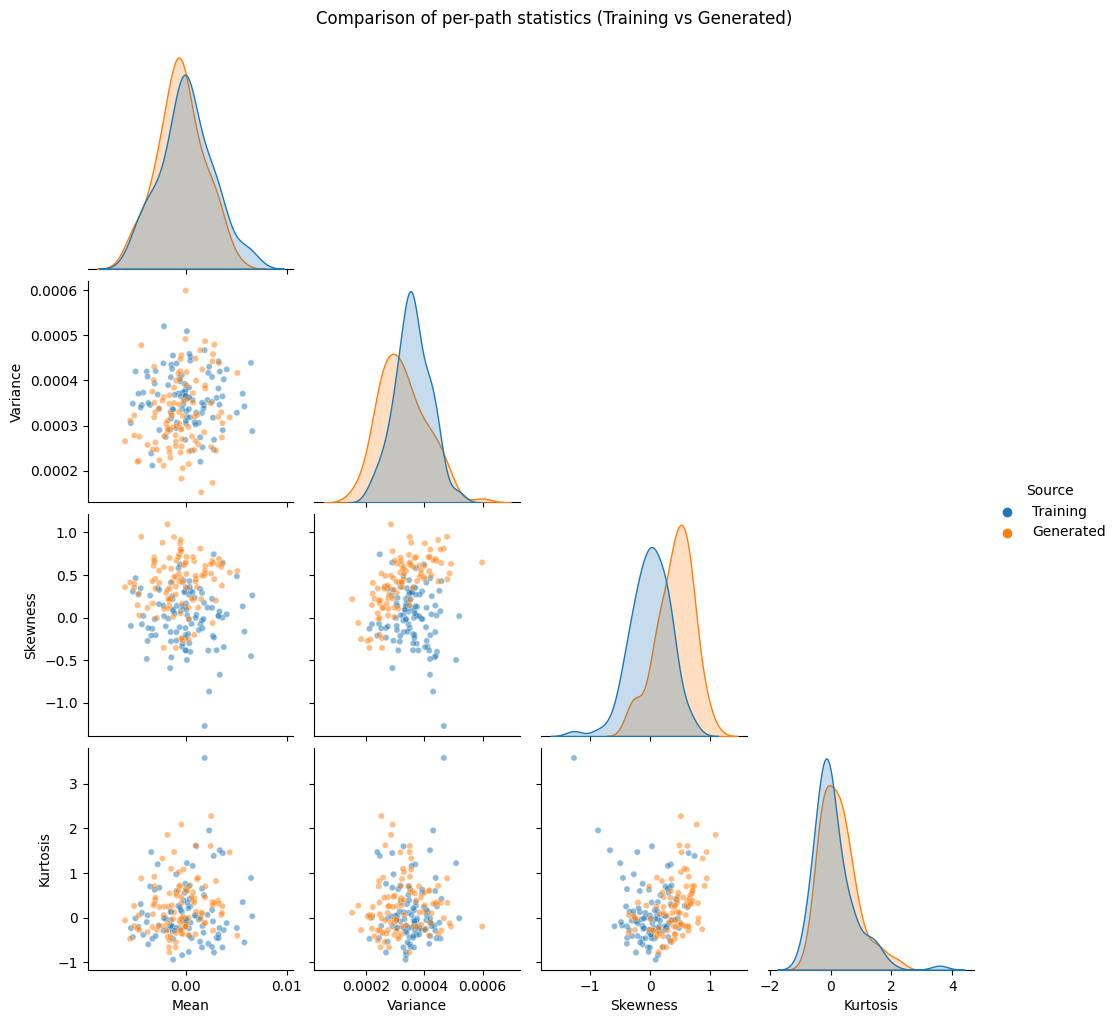

KS test on     Mean: statistic=0.180, p-value=0.078
KS test on Variance: statistic=0.310, p-value=0.000
KS test on Skewness: statistic=0.540, p-value=0.000
KS test on Kurtosis: statistic=0.210, p-value=0.024
Linear kernel MMD^2: 0.1903
RBF kernel MMD^2 = 1.3656e-01,  sigma = 0.512

=== Evaluating hybrid on logrets ===


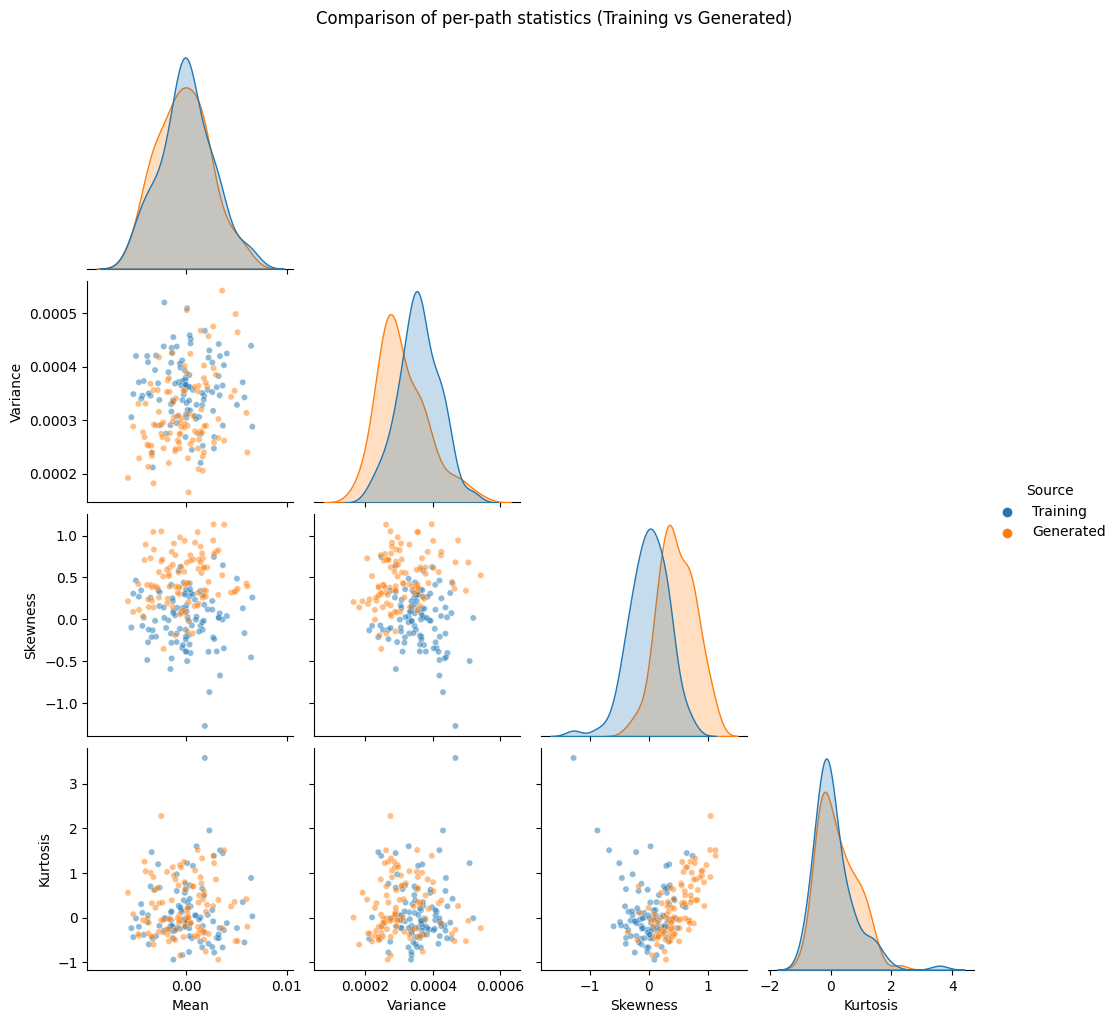

KS test on     Mean: statistic=0.110, p-value=0.583
KS test on Variance: statistic=0.410, p-value=0.000
KS test on Skewness: statistic=0.560, p-value=0.000
KS test on Kurtosis: statistic=0.160, p-value=0.155
Linear kernel MMD^2: 0.2353
RBF kernel MMD^2 = 1.5176e-01,  sigma = 0.519

=== Evaluating krr on logrets ===


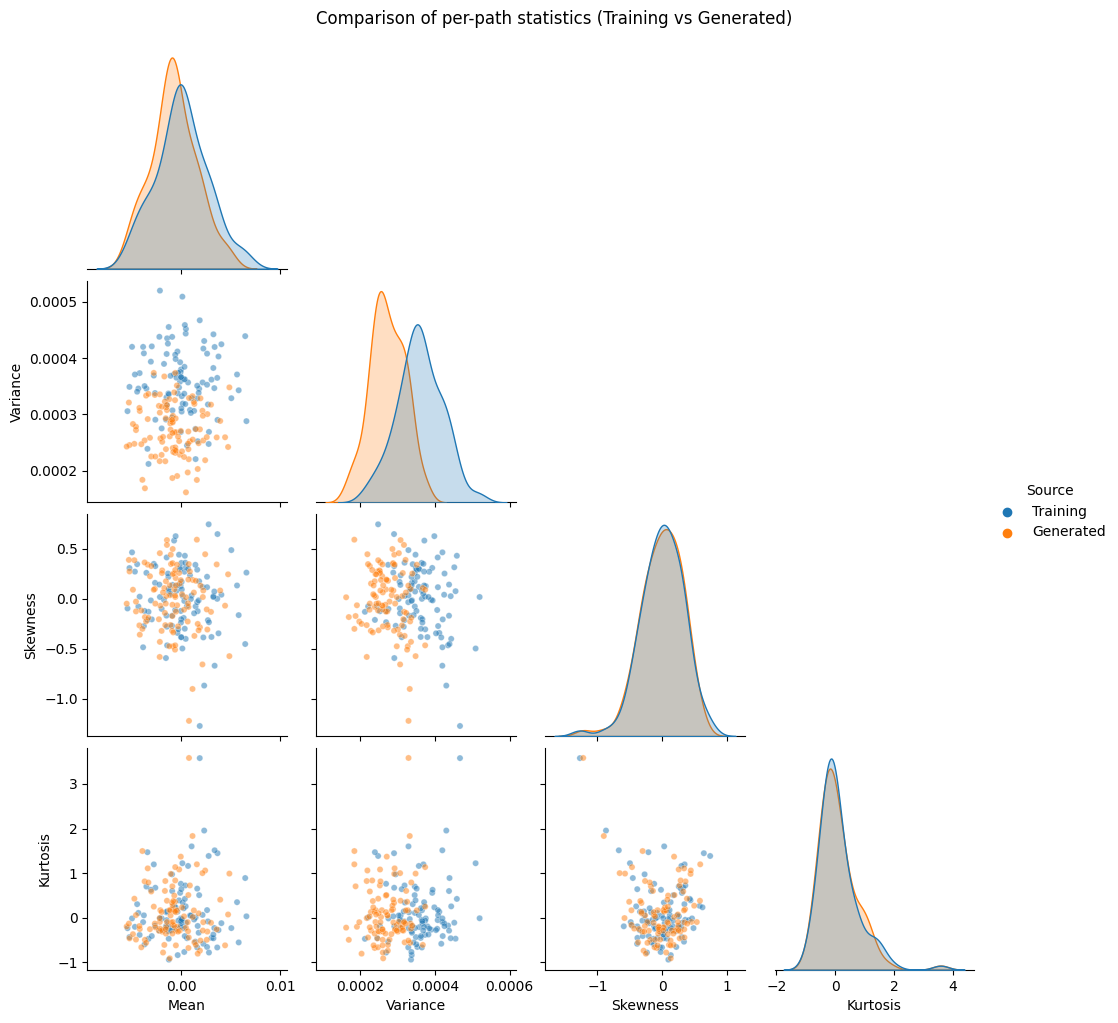

KS test on     Mean: statistic=0.250, p-value=0.004
KS test on Variance: statistic=0.620, p-value=0.000
KS test on Skewness: statistic=0.050, p-value=1.000
KS test on Kurtosis: statistic=0.070, p-value=0.968
Linear kernel MMD^2: 0.0002
RBF kernel MMD^2 = -1.0442e-02,  sigma = 0.472

=== Evaluating arima on logrets ===


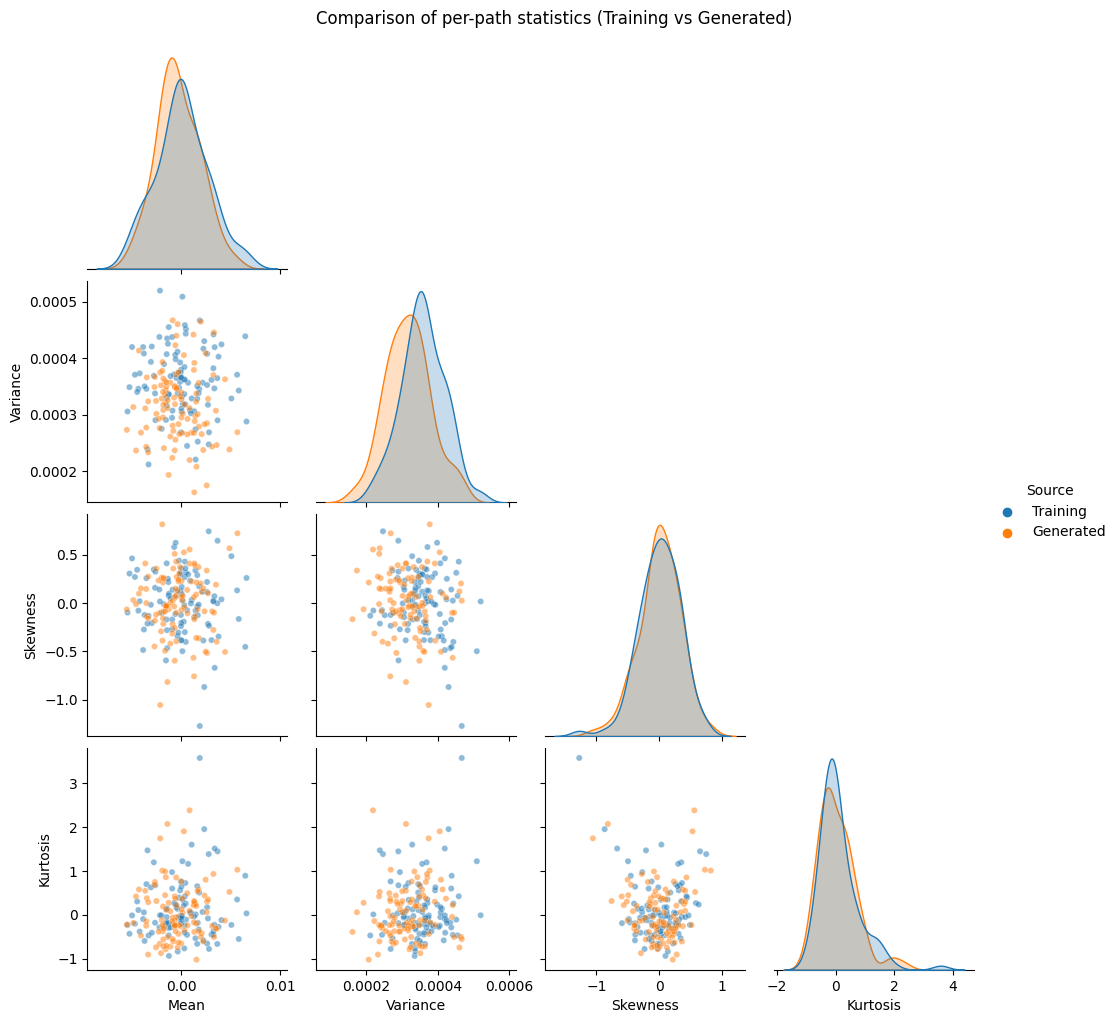

KS test on     Mean: statistic=0.150, p-value=0.211
KS test on Variance: statistic=0.330, p-value=0.000
KS test on Skewness: statistic=0.070, p-value=0.968
KS test on Kurtosis: statistic=0.110, p-value=0.583
Linear kernel MMD^2: 0.0039
RBF kernel MMD^2 = -2.8164e-03,  sigma = 0.482

=== Evaluating garch on logrets ===


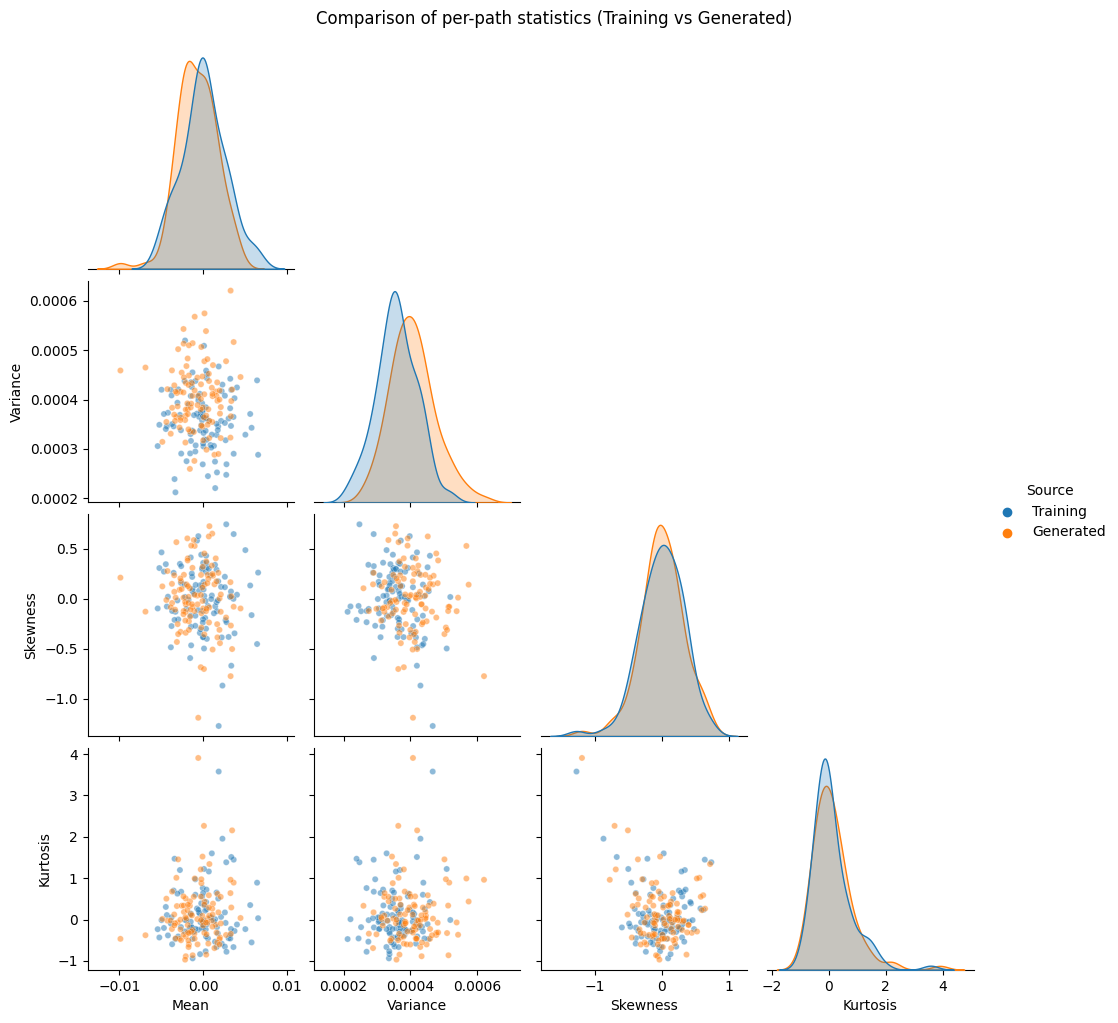

KS test on     Mean: statistic=0.190, p-value=0.054
KS test on Variance: statistic=0.340, p-value=0.000
KS test on Skewness: statistic=0.080, p-value=0.908
KS test on Kurtosis: statistic=0.080, p-value=0.908
Linear kernel MMD^2: 0.0004
RBF kernel MMD^2 = -6.9424e-03,  sigma = 0.473

=== Evaluating bootstrap on prices ===


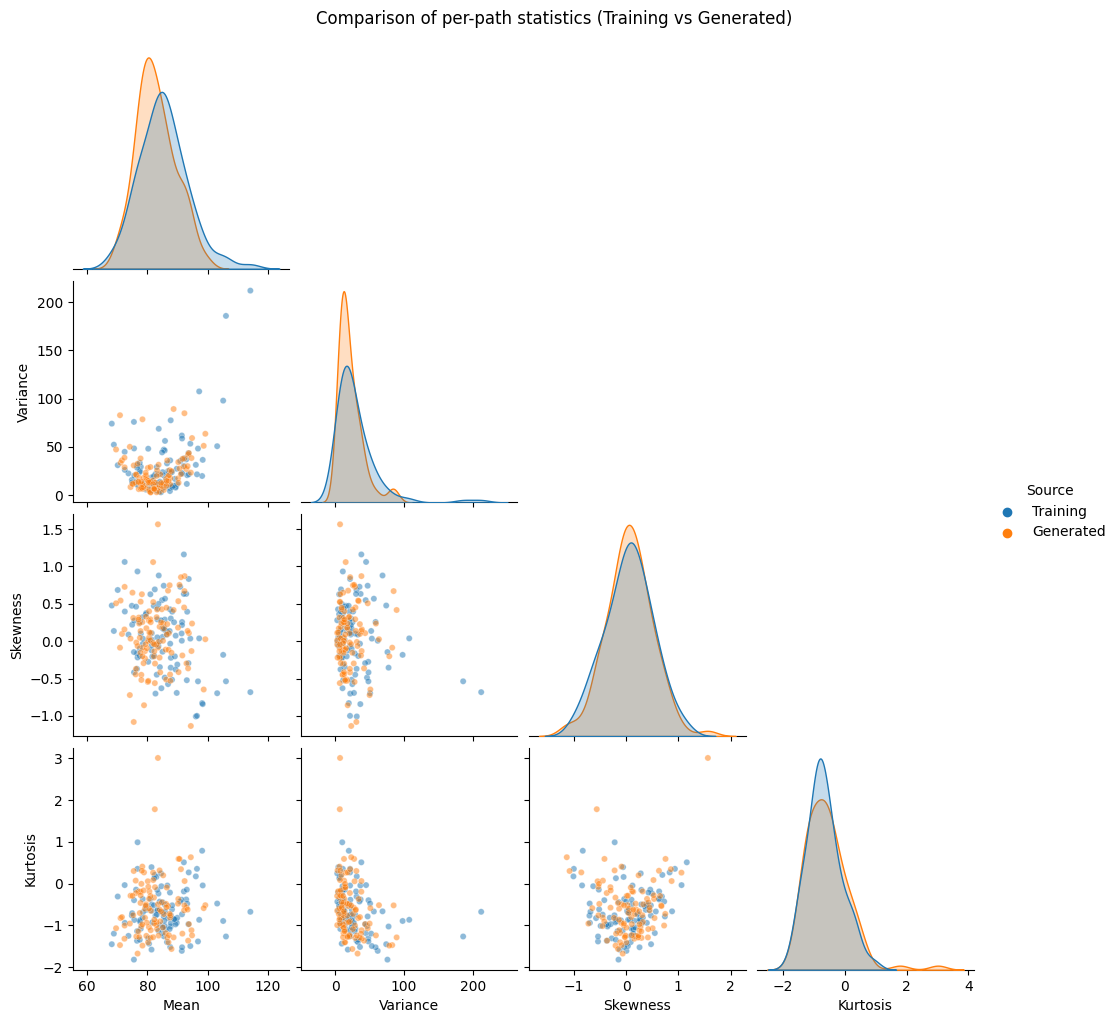

KS test on     Mean: statistic=0.190, p-value=0.054
KS test on Variance: statistic=0.150, p-value=0.211
KS test on Skewness: statistic=0.060, p-value=0.994
KS test on Kurtosis: statistic=0.110, p-value=0.583
Linear kernel MMD^2: 61.5548
RBF kernel MMD^2 = 9.0626e-03,  sigma = 12.521

=== Evaluating hybrid on prices ===


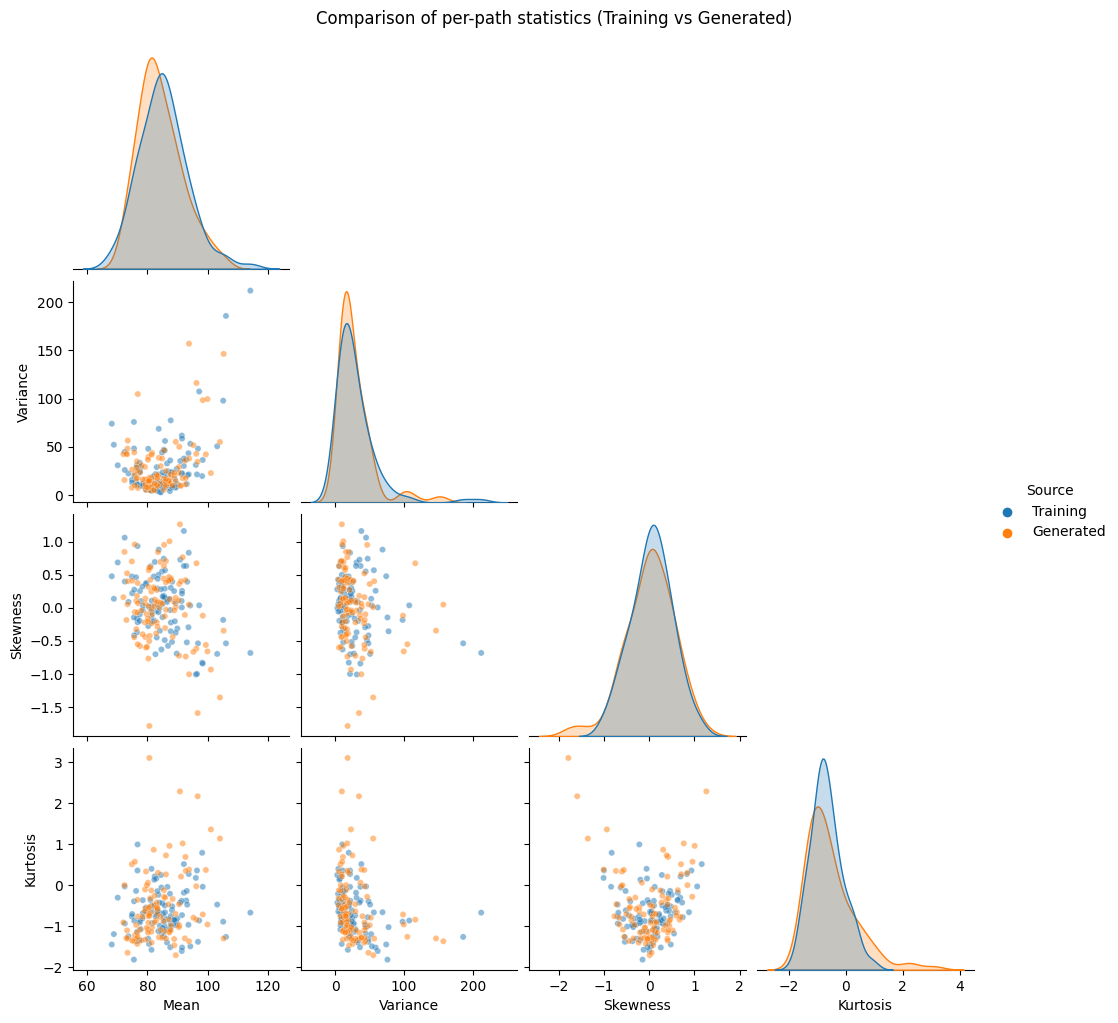

KS test on     Mean: statistic=0.140, p-value=0.282
KS test on Variance: statistic=0.110, p-value=0.583
KS test on Skewness: statistic=0.060, p-value=0.994
KS test on Kurtosis: statistic=0.110, p-value=0.583
Linear kernel MMD^2: 2.3825
RBF kernel MMD^2 = -3.0600e-03,  sigma = 13.303

=== Evaluating krr on prices ===


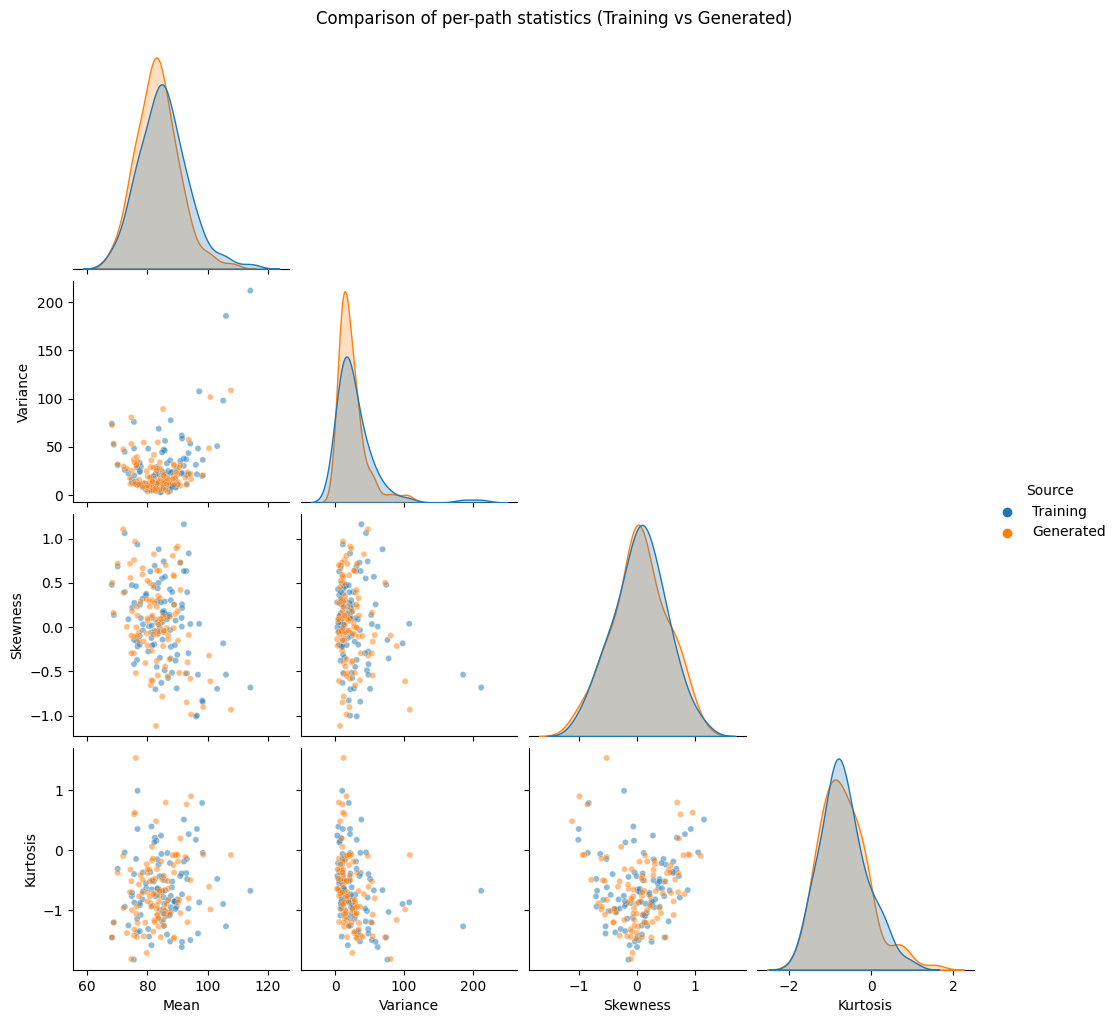

KS test on     Mean: statistic=0.140, p-value=0.282
KS test on Variance: statistic=0.130, p-value=0.368
KS test on Skewness: statistic=0.070, p-value=0.968
KS test on Kurtosis: statistic=0.070, p-value=0.968
Linear kernel MMD^2: 36.8074
RBF kernel MMD^2 = 1.7654e-03,  sigma = 12.709

=== Evaluating arima on prices ===


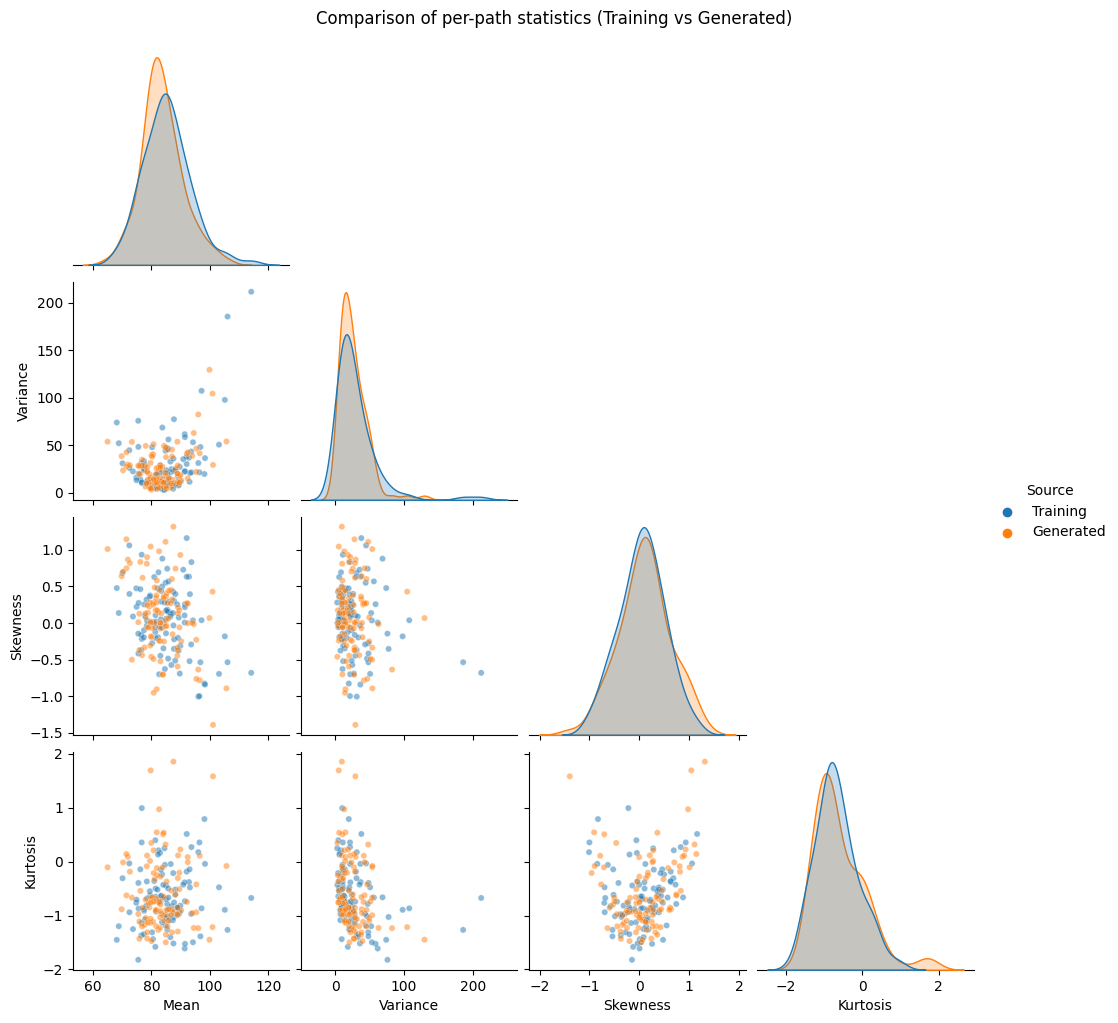

KS test on     Mean: statistic=0.160, p-value=0.155
KS test on Variance: statistic=0.090, p-value=0.815
KS test on Skewness: statistic=0.090, p-value=0.815
KS test on Kurtosis: statistic=0.090, p-value=0.815
Linear kernel MMD^2: 14.2068
RBF kernel MMD^2 = -1.6031e-03,  sigma = 13.416

=== Evaluating garch on prices ===


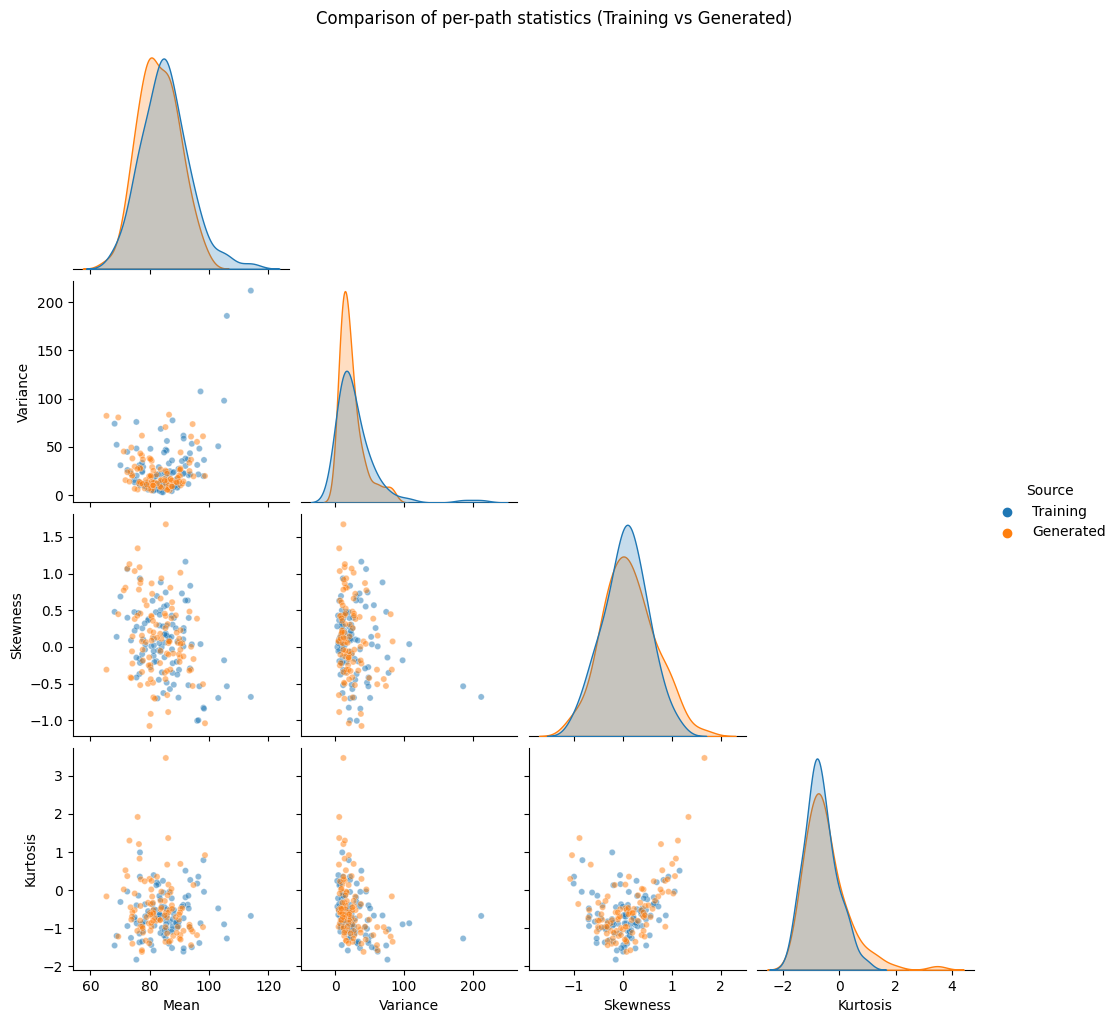

KS test on     Mean: statistic=0.200, p-value=0.036
KS test on Variance: statistic=0.150, p-value=0.211
KS test on Skewness: statistic=0.100, p-value=0.702
KS test on Kurtosis: statistic=0.120, p-value=0.470
Linear kernel MMD^2: 42.7157
RBF kernel MMD^2 = 3.7133e-03,  sigma = 12.447

Summary (log-returns):
 bootstrap: MMD^2_lin=1.9026e-01, MMD^2_rbf=1.3656e-01, KS p-vals=[0.078, 0.0, 0.0, 0.024]
    hybrid: MMD^2_lin=2.3533e-01, MMD^2_rbf=1.5176e-01, KS p-vals=[0.583, 0.0, 0.0, 0.155]
       krr: MMD^2_lin=2.0768e-04, MMD^2_rbf=-1.0442e-02, KS p-vals=[0.004, 0.0, 1.0, 0.968]
     arima: MMD^2_lin=3.9078e-03, MMD^2_rbf=-2.8164e-03, KS p-vals=[0.211, 0.0, 0.968, 0.583]
     garch: MMD^2_lin=3.9953e-04, MMD^2_rbf=-6.9424e-03, KS p-vals=[0.054, 0.0, 0.908, 0.908]

Summary (prices):
 bootstrap: MMD^2_lin=6.1555e+01, MMD^2_rbf=9.0626e-03, KS p-vals=[0.054, 0.211, 0.994, 0.583]
    hybrid: MMD^2_lin=2.3825e+00, MMD^2_rbf=-3.0600e-03, KS p-vals=[0.282, 0.583, 0.994, 0.583]
       krr: MMD^2_li

In [25]:
res_log = evaluate_models(fut_prices, fut_logrets, gen_price, gen_logret, use="logret")
res_px  = evaluate_models(fut_prices, fut_logrets, gen_price, gen_logret, use="price")

print("\nSummary (log-returns):")
for k, v in res_log.items():
    print(f"{k:>10}: MMD^2_lin={v['mmd_linear']:.4e}, MMD^2_rbf={v['mmd_rbf']:.4e}, "
          f"KS p-vals={np.round(v['ks_pvals'],3).tolist()}")

print("\nSummary (prices):")
for k, v in res_px.items():
    print(f"{k:>10}: MMD^2_lin={v['mmd_linear']:.4e}, MMD^2_rbf={v['mmd_rbf']:.4e}, "
          f"KS p-vals={np.round(v['ks_pvals'],3).tolist()}")
